# UNO Vision

Image Analysis and Pattern Recognition - Final Project

Group 34

Fiona Dematraz & Killian Ballifard & Gabriel Marival

## 0. Setup

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os
sys.path.insert(0, os.path.abspath(".."))
from project.scripts.preprocessing.sectors import slice_sectors
from project.scripts.preprocessing import preprocess
from project.scripts.preprocessing.rygb import rygb2rgb
from project.scripts.dataset import load_train_images_paths_and_labels
from project.scripts.token import detect_active_player, is_white_background

## 1. Introduction

Automatically understanding the state of a game from a visual input is a complex problem that combines object detection, classification, and spatial reasoning. For the project, this problem is placed in the context of the game UNO, with the goal of inferring the complete state of a game from a single top-down photograph of the table.

From a single image, the system must predict the central card in play, the active player, and the set of cards held by each of the four players. Players occupy fixed spatial positions around the table, and the active player is indicated by a physical token placed next to their hand. The dataset presents two main difficulties: the background variability (plain white vs. noisy patterned) and the card layout complexity (non-overlapping vs. overlapping).

To address this, a pipeline was designed with two parallel branches: one for detecting the active token via color segmentation and shape filtering, and the other for card recognition, which divides the image into spatial sectors, converts them to a 4-color HSV representation, and classifies each sector using a CNN with attention pooling. The final game state is assembled by combining the two outputs and evaluated using a weighted score of center card accuracy (10%), active player accuracy (10%), and per-player F1 score (80%).

## 2. Dataset

The dataset consists of top-down photographs taken during actual UNO games, captured under a variety of conditions. There are two types of backgrounds: plain white backgrounds, which provide a clean, easy-to-segment environment, and backgrounds with busy patterns (such as a tablecloth with leaf patterns), which make isolating the cards significantly more difficult. For each background type, the dataset includes both non-overlapping and overlapping card layouts, with the latter being more challenging to process because the card edges are partially obscured.

Each image depicts up to four players positioned at fixed locations around the table (bottom, right, top, left), though not all images necessarily contain four players. In the center of the table is the active discard pile. The active player is indicated by a physical token—a small dark cube or a yellow coin—placed next to their hand of cards.

The cards fall into 54 distinct categories: number cards (0–9) in four colors (red, green, blue, yellow), as well as action cards (Pass, Reverse, Draw Two) and wild cards (Wild, Wild Draw Four).

## 3. Methodology 

### 3.1 Overview

### 3.2 Active Token Detection


The goal of this branch is to find the active player token in the image and assign it to one of the four player zones.

#### Step 1 : Background Detection

The first step determines which type of token to look for. The four corners of the image are sampled, which always contain background and never cards. If the mean brightness of these corners exceeds 200, the scene is classified as a white background; otherwise, it is classified as a flower background. This distinction lets know which token types are: white background always use a black rectangular token, while flower background always use a yellow circular token.

#### Step 2 : Color Masking

Depending on the background type, a binary mask is computed on the full image.

- **White background** : an HSV threshold with `V < 130` and `S < 90` is applied to isolate dark pixels corresponding to the black token. Morphological closing (15×15 kernel) fills internal gaps, followed by opening (7×7 kernel) to remove noise.
- **Flower background** : the preprocessing pipeline's color segmentation function, already calibrated for UNO card colors,is used to produce a soft yellow confidence map, which is then thresholded at 40 to obtain a binary mask.

#### Step 3 : Blob Selection

For each contour extracted from the binary mask, a set of shape descriptors is computed:

| Descriptor | Formula | Ideal value |
|---|---|---|
| Circularity | `4π × area / perimeter²` | 1.0 = perfect circle |
| Solidity | `area / convex_hull_area` | 1.0 = fully solid |
| Aspect ratio | `max(w,h) / min(w,h)` | 1.0 = square |
| Rect fill *(black only)* | `area / minAreaRect_area` | 1.0 = solid rectangle |
| Yellow density *(yellow only)* | fraction of yellow pixels inside blob | filters hollow symbols |

**Yellow token selection** : a candidate must satisfy:
- `circularity > 0.65` (round shape)
- `solidity > 0.65` (solid interior)
- `yellow_density > 0.55` (uniformly filled — rejects Skip card circles which have white holes)

The blob maximizing `circularity × solidity × yellow_density` is selected.

**Black token selection** : a candidate must satisfy:
- `circularity < 0.82` (non-circular, i.e. rectangular)
- `aspect_ratio > 1.1` (elongated)
- `rect_fill > 0.65` (solid rectangle, not a hollow card symbol)

Among valid candidates, the largest blob by area is retained, as the token is the biggest dark solid object in the scene.

#### Step 4 : Player Assignment

The centroid `(cx, cy)` of the detected token is mapped to the nearest player zone using Euclidean distance:

```
active_player = argmin_p  distance(token_center, player_zone_center_p)
```

The four zone centers are fixed image coordinates corresponding to P1 (bottom), P2 (right), P3 (top), and P4 (left).



### 3.3 Preprocessing 

The preprocessing pipeline takes a raw RGB image of shape 3 × W × H and produces 5 normalized RYGB color maps of shape 5 × 4 × w × h, one per player zone and the center, ready to be fed into the classifier. Each step is applied independently to each sector.

#### Sector Splitting and Reorientation

The image is divided into 5 fixed rectangular sectors of size 2000×1000 pixels, corresponding to the center pile and the four player zones (P1 bottom, P2 right, P3 top, P4 left). Since players are positioned on all four sides of the table, sectors for P2, P3 and P4 are rotated to a canonical orientation:

- P2 (right): rotated 90° clockwise
- P3 (top): rotated 180°
- P4 (left): rotated 90° counter-clockwise

After reorientation, all sectors share the same 2000×1000 layout with cards always appearing in the same reading direction, giving a tensor of shape 5 × 3 × w × h.

#### HSV Conversion and RYGB Color Mapping

Each sector is converted from RGB to HSV, which separates chromatic information (hue, saturation) from brightness (value), making color identification more robust to lighting variations.

Each pixel is then mapped to a soft confidence score for each of the four UNO card colors (Red, Yellow, Green, Blue) producing a custom 4-channel RYGB representation. The score is computed as a normalized L-infinity distance in HSV space:

score = 1 - max( |H - H_mean| / H_tol,
                 |S - S_mean| / S_tol,
                 |V - V_mean| / V_tol )

score = clip(score, 0, 1)

The mean and tolerance values per color were calibrated from manually segmented card samples by computing the circular mean and standard deviation in HSV space for each color, and setting the tolerance to 6 standard deviations. Hue wrap-around (red spanning the 0°/180° boundary) is handled explicitly by taking the minimum of the direct and wrapped distances.

The black component (card numbers and symbols) is computed separately using the same scoring function and added to all four channels, so that black pixels contribute a positive signal in every channel regardless of card color. Pixels that do not match any of the five targets, such as the flower background, receive a score of 0 across all channels, acting as an implicit background suppression without any explicit segmentation step. The output at this stage is a tensor of shape 5 × 4 × w × h.

#### Area Bandpass Filtering

A connected component analysis is applied on the combined binary mask (logical OR across all 4 channels). Only components with an area between 3,000 and 90,000 pixels are retained, filtering out both small noise artifacts and large background regions, keeping only card-sized blobs.

#### Random Cropping (Training Augmentation)

During training, a data augmentation step randomly zeros out 16 cells of 250×250 pixels from a grid partitioning the sector. This encourages the model to be robust to partial occlusions and overlapping cards.


### 3.4 CNN

## 4. Results 

### 4.1 Active player detection

The detection works reliably on both background types. On white background images, the black token produces a clean binary mask with very few false positives, as the dark rectangular shape stands out clearly. On flower background images, the yellow soft mask successfully suppresses the leaf pattern while retaining the token blob. The centroid is then correctly mapped to the nearest player zone in both cases. Examples are shown below.

Loading all train images paths with their labels
  Debug saved to /tmp/debug_image_0.png
  Debug saved to /tmp/debug_image_1.png


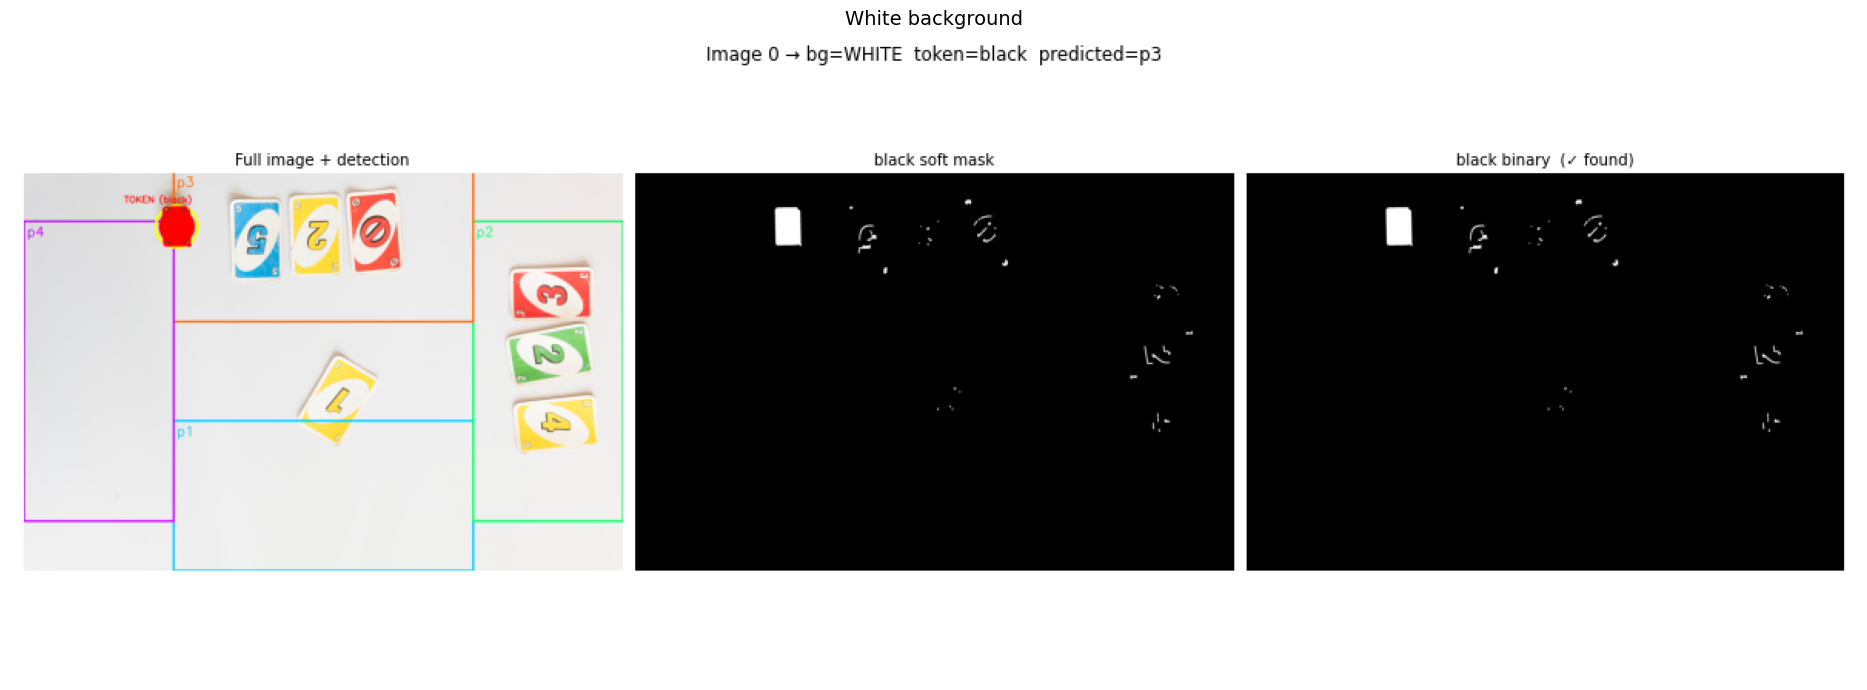

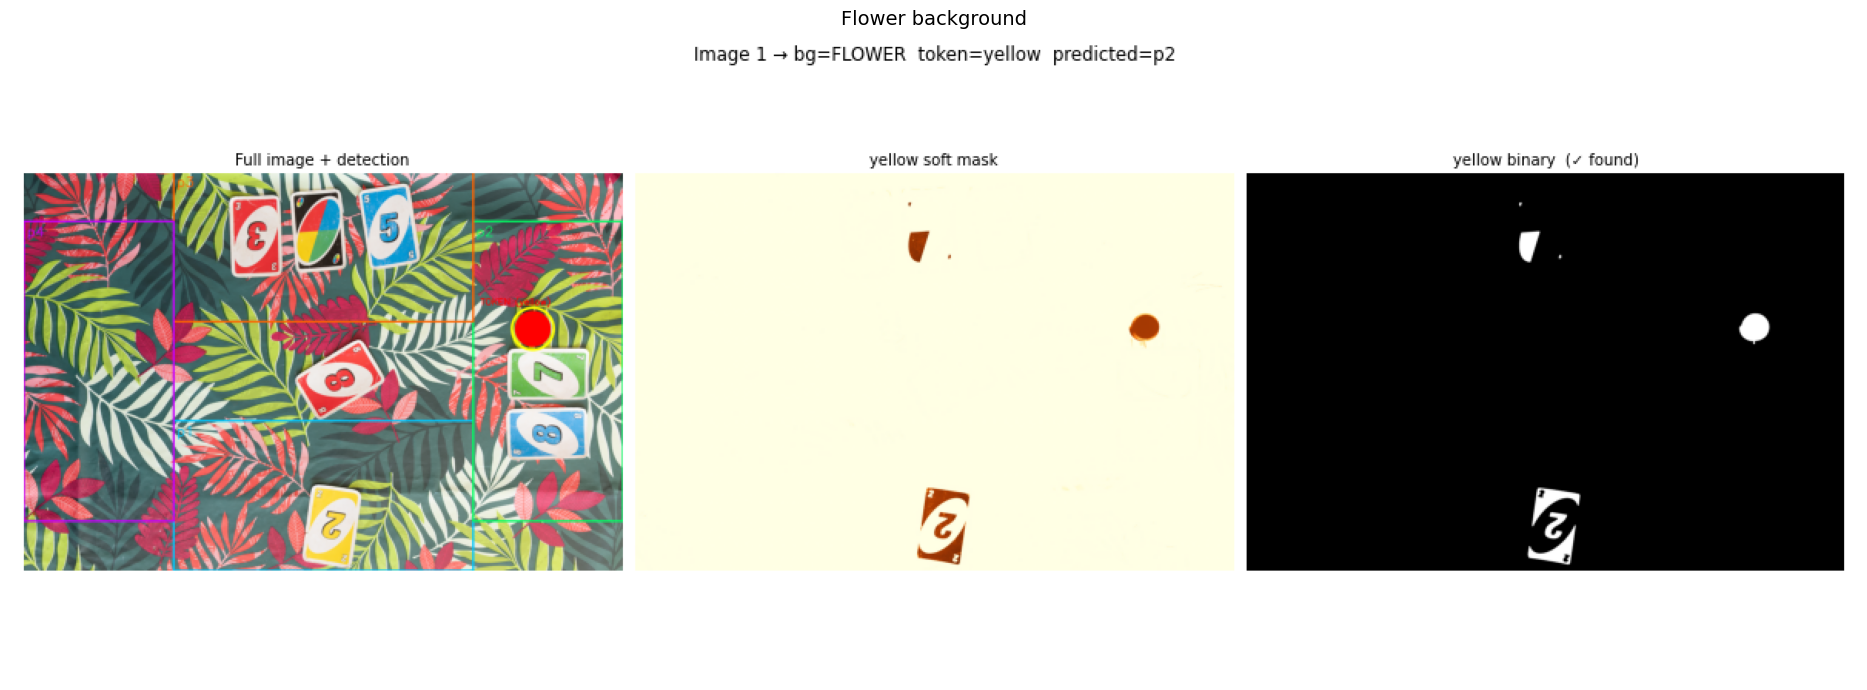

In [9]:
# Load dataset
dataset = load_train_images_paths_and_labels()

# Find one white and one flower background image
white_img, flower_img = None, None
for path, _ in dataset:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    if white_img is None and is_white_background(img):
        white_img = img
    if flower_img is None and not is_white_background(img):
        flower_img = img
    if white_img is not None and flower_img is not None:
        break

# Run detection on both
detect_active_player([white_img, flower_img], debug=True)

# Display both inline
for i, title in enumerate(["White background", "Flower background"]):
    img = mpimg.imread(f"/tmp/debug_image_{i}.png")
    plt.figure(figsize=(20, 7))
    plt.title(title, fontsize=14)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

### 4.2 Preprocessing 

The RYGB color mapping effectively suppresses the background in both white and flower scenes, leaving only card-colored regions with meaningful signal. Empty player zones are correctly output as fully black sectors. One notable observation is that the yellow active player token appears in the yellow channel when present in a sector, which is expected and handled downstream by the token detection branch. Examples are shown below.

Loading all train images paths with their labels


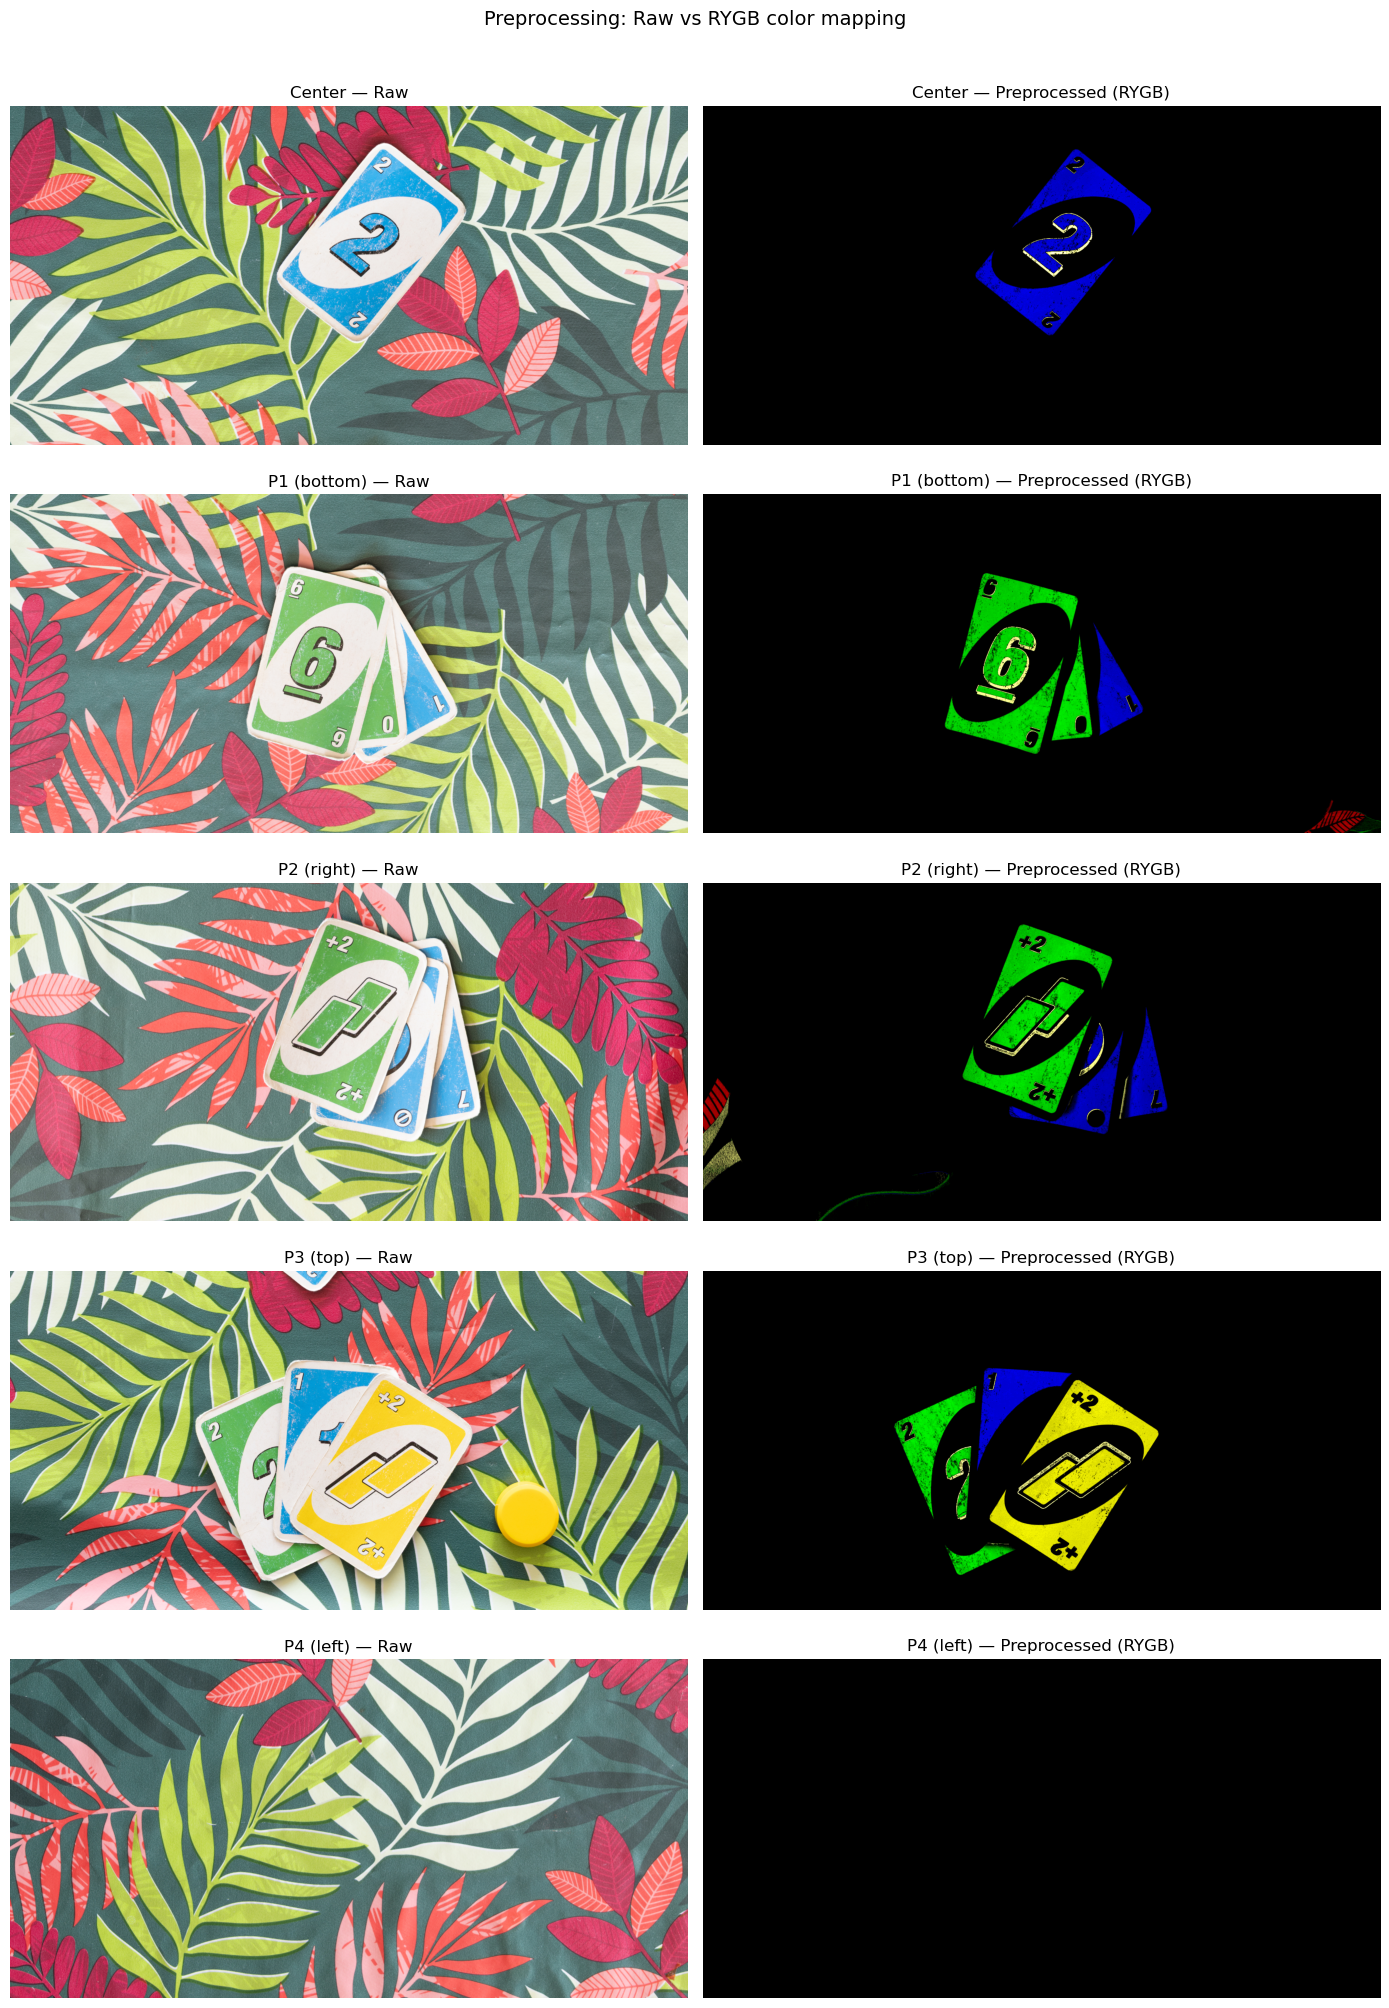

In [9]:


SECTOR_NAMES = ["Center", "P1 (bottom)", "P2 (right)", "P3 (top)", "P4 (left)"]

# Load a random image
dataset = load_train_images_paths_and_labels()
path, label = dataset[np.random.randint(len(dataset))]
image = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

# Slice into sectors
sectors = slice_sectors(image)

# Plot raw vs preprocessed for each sector
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, (sector, name) in enumerate(zip(sectors, SECTOR_NAMES)):
    preprocessed = preprocess(sector)
    preview = rygb2rgb(preprocessed)

    axes[i, 0].imshow(sector)
    axes[i, 0].set_title(f"{name} — Raw")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(preview)
    axes[i, 1].set_title(f"{name} — Preprocessed (RYGB)")
    axes[i, 1].axis("off")

plt.suptitle("Preprocessing: Raw vs RYGB color mapping", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Discussion

## 7. Conclusion